# Saliency-Driven Gaze Simulation: Saliency Comparison

**Course:** Natural Interaction, Universita degli Studi di Milano, 2025-2026  
**Author:** Arash Khosropour  
**Supervisors:** Prof. Giuseppe Boccignone, Prof. Alessandro D'Amelio

---

## What this notebook shows

We reverse-engineered [SaccadeJEPA](https://github.com/LumenPallidium/jepa) and found that its saccade targets are selected uniformly at random. The key line in `saccade.py` (line 66) is:

```python
translations = torch.empty(b, 2).uniform_(-max_frac, max_frac)  # purely random
```

There is no content-based attention. SaccadeJEPA is a representation learning model that uses random affine jitter as augmentation — the saccade is the augmentation, not the output.

**The question:** if we replace that random line with a learned saliency model trained on real human eye-tracking data, how much does gaze simulation improve?

We compare five saliency sources against human fixation data from the FIND dataset:

| # | Source | Type |
|---|---|---|
| 1 | **Random** | Uniform noise — what SaccadeJEPA does |
| 2 | **Center bias** | Fixed Gaussian at image center, no learning |
| 3 | **Itti-Koch** | Classical spectral residual saliency (Hou & Zhang, CVPR 2007) |
| 4 | **ResNetSaliency** | ResNet-18 (ImageNet pretrained) + conv head trained on FIND |
| 5 | **I-JEPA Saliency** | I-JEPA ViT-H/14 (self-supervised) + conv head trained on FIND |


In [1]:
import sys
sys.path.insert(0, '..')

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.find_data import (
    load_frame, load_fixations, get_frame_fixations,
    rescale_fixations, make_heatmap, get_video_size
)
from src.saliency.random_saliency import RandomSaliency
from src.saliency.center_bias import CenterBiasParametric
from src.saliency.itti_koch import get_classical_saliency
from src.saliency.resnet_saliency import ResNetSaliency
from src.saliency.ijepa_saliency import IJepaSaliency
from src.saliency.learned import IMAGE_TRANSFORM

DATA_ROOT        = 'f:/university/milan/NI/info/Gaze_Jepa/find_dataset'
CHECKPOINT       = '../checkpoints/resnet_saliency_best.pt'
IJEPA_CHECKPOINT = '../checkpoints/ijepa_saliency_best.pt'

SOURCES = [
    (RandomSaliency(),                        'Random (SaccadeJEPA)'),
    (CenterBiasParametric(),                  'Center bias'),
    (get_classical_saliency(),                'Itti-Koch'),
    (ResNetSaliency.load(CHECKPOINT),         'ResNetSaliency (ours)'),
    (IJepaSaliency.load(IJEPA_CHECKPOINT),    'I-JEPA Saliency (ours)'),
]

print(f'Ready. {len(SOURCES)} sources loaded.')


Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Ready. 5 sources loaded.


## 1. The FIND Dataset

FIND contains eye-tracking data from **39 observers** watching **65 multi-face social videos** at 1280×720 resolution. For each frame we have the pixel coordinates of every observer's fixation — this is the ground truth.

Fixation data is stored in `.mat` files (`fix_data_NEW/`, key `curr_v_all_s`, shape `(39, n_frames, 2)`).

Videos are split by ID to prevent temporal data leakage:
- **Train:** videos 001–063
- **Val:** videos 064–069
- **Test:** videos 070–075

The ground truth heatmap for a frame is built by placing a Gaussian (σ=20px) at each observer's fixation, summing all Gaussians, and normalizing to sum=1.


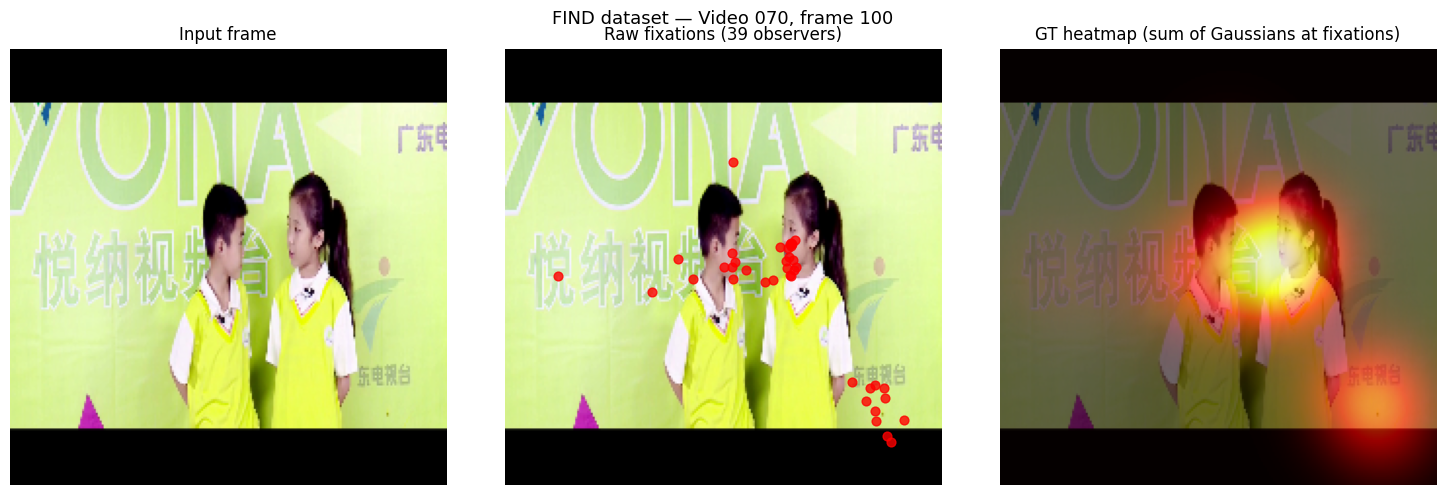

In [2]:
VIDEO_ID  = '070'
FRAME_IDX = 100

frame      = load_frame(DATA_ROOT, VIDEO_ID, FRAME_IDX, size=224)
fix_array  = load_fixations(DATA_ROOT, VIDEO_ID)
src_size   = get_video_size(DATA_ROOT, VIDEO_ID)
raw_fix    = get_frame_fixations(fix_array, FRAME_IDX)
gt_fix     = rescale_fixations(raw_fix, src_size, (224, 224))
gt_heatmap = make_heatmap(gt_fix, 224, sigma_pixels=20.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(frame)
axes[0].set_title('Input frame', fontsize=12)
axes[0].axis('off')

axes[1].imshow(frame)
axes[1].scatter(gt_fix[:, 0], gt_fix[:, 1], c='red', s=40, alpha=0.8)
axes[1].set_title(f'Raw fixations ({len(gt_fix)} observers)', fontsize=12)
axes[1].axis('off')

axes[2].imshow(frame)
axes[2].imshow(gt_heatmap, cmap='hot', alpha=0.6)
axes[2].set_title('GT heatmap (sum of Gaussians at fixations)', fontsize=12)
axes[2].axis('off')

plt.suptitle(f'FIND dataset — Video {VIDEO_ID}, frame {FRAME_IDX}', fontsize=13)
plt.tight_layout()
plt.savefig('../report_arash/figures/find_dataset.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Five Saliency Sources on the Same Frame

Each model takes a 224×224 ImageNet-normalized tensor and outputs a probability map over all pixels (values are non-negative and sum to 1). Overlaid on the input frame with a hot colormap — brighter = higher predicted fixation probability. The rightmost panel is the human ground truth.


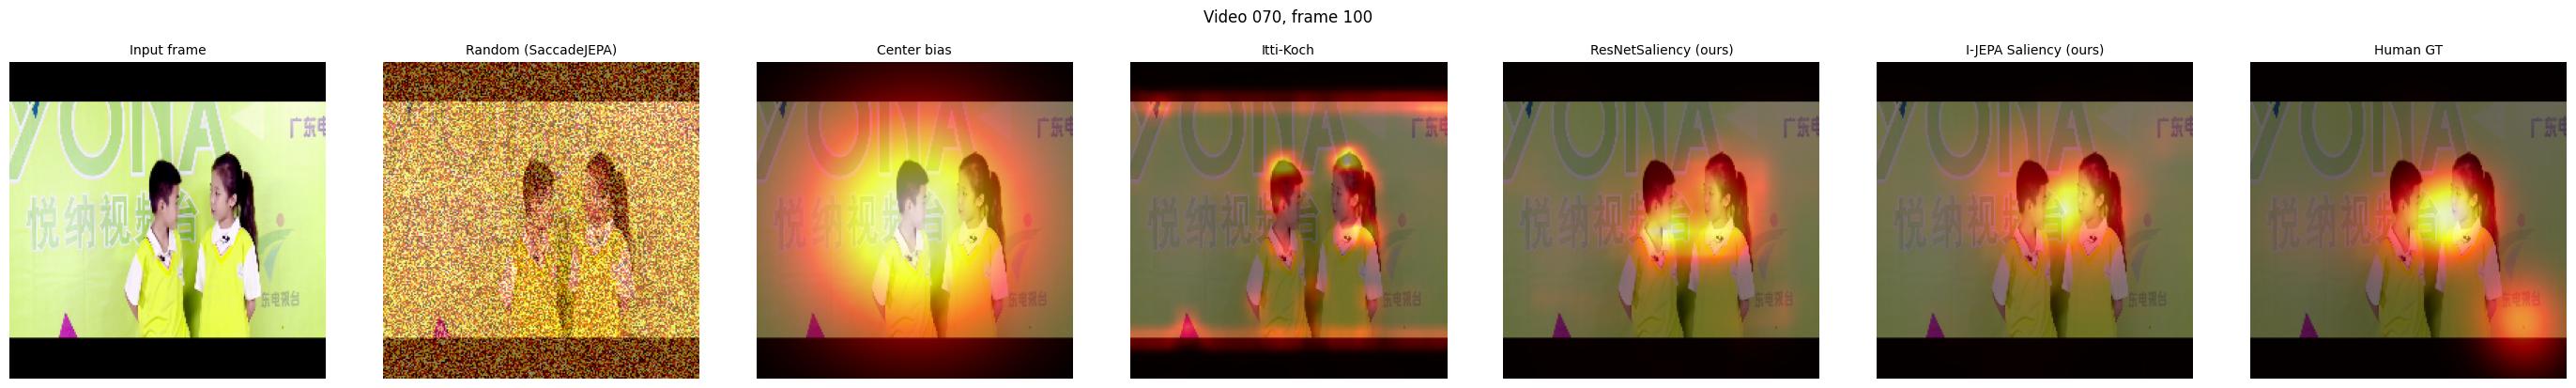

In [3]:
image_tensor = IMAGE_TRANSFORM(frame).unsqueeze(0)

with torch.no_grad():
    saliency_maps = [src(image_tensor)[0].numpy() for src, _ in SOURCES]

n = len(SOURCES)
fig, axes = plt.subplots(1, n + 2, figsize=((n + 2) * 4, 4))

axes[0].imshow(frame)
axes[0].set_title('Input frame', fontsize=10)
axes[0].axis('off')

for ax, sal, (_, title) in zip(axes[1:n+1], saliency_maps, SOURCES):
    ax.imshow(frame)
    ax.imshow(sal, cmap='hot', alpha=0.55)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

axes[-1].imshow(frame)
axes[-1].imshow(gt_heatmap, cmap='hot', alpha=0.6)
axes[-1].set_title('Human GT', fontsize=10)
axes[-1].axis('off')

plt.suptitle(f'Video {VIDEO_ID}, frame {FRAME_IDX}', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../report_arash/figures/saliency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Second Example

Same comparison on a different video to verify consistency across scenes.


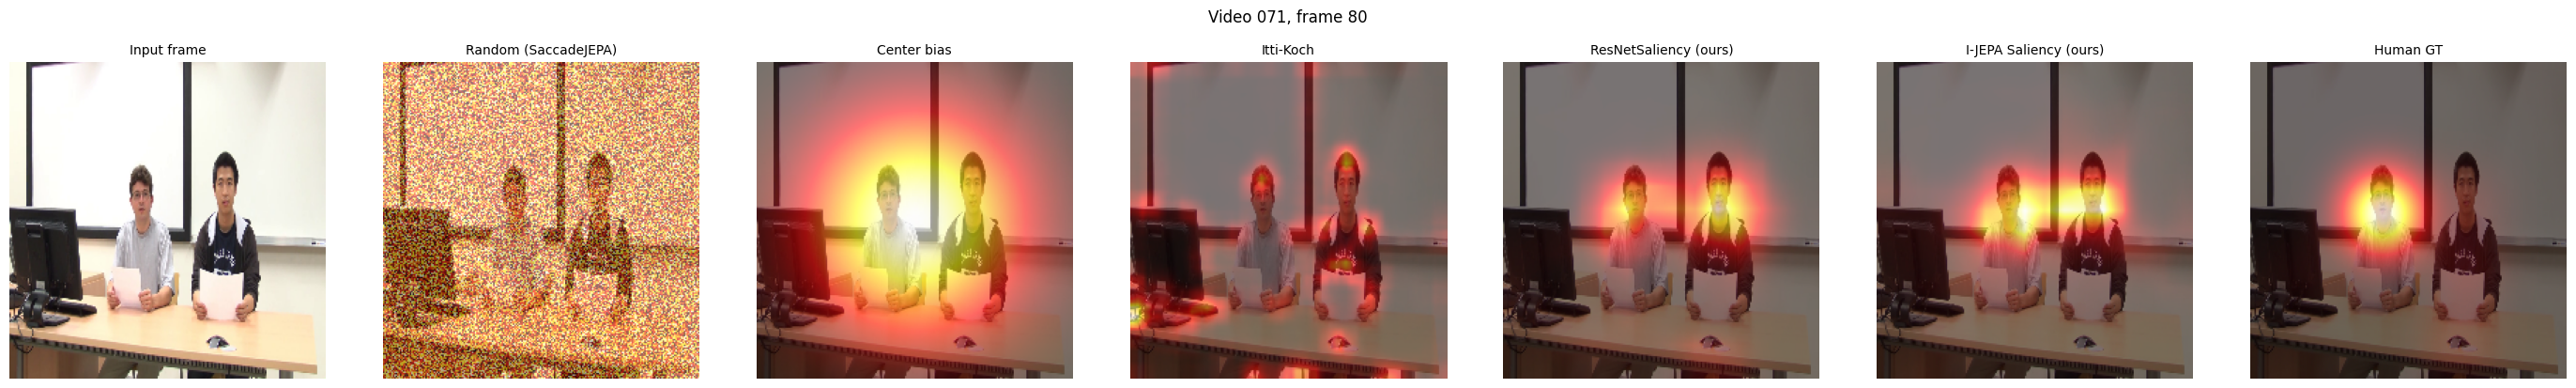

In [4]:
VIDEO_ID_2  = '071'
FRAME_IDX_2 = 80

fix_array2  = load_fixations(DATA_ROOT, VIDEO_ID_2)
frame2      = load_frame(DATA_ROOT, VIDEO_ID_2, FRAME_IDX_2, size=224)
src_size2   = get_video_size(DATA_ROOT, VIDEO_ID_2)
raw_fix2    = get_frame_fixations(fix_array2, FRAME_IDX_2)
gt_fix2     = rescale_fixations(raw_fix2, src_size2, (224, 224))
gt_heatmap2 = make_heatmap(gt_fix2, 224, sigma_pixels=20.0)
img_tensor2 = IMAGE_TRANSFORM(frame2).unsqueeze(0)

with torch.no_grad():
    saliency_maps2 = [src(img_tensor2)[0].numpy() for src, _ in SOURCES]

n = len(SOURCES)
fig, axes = plt.subplots(1, n + 2, figsize=((n + 2) * 4, 4))

axes[0].imshow(frame2)
axes[0].set_title('Input frame', fontsize=10)
axes[0].axis('off')

for ax, sal, (_, title) in zip(axes[1:n+1], saliency_maps2, SOURCES):
    ax.imshow(frame2)
    ax.imshow(sal, cmap='hot', alpha=0.55)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

axes[-1].imshow(frame2)
axes[-1].imshow(gt_heatmap2, cmap='hot', alpha=0.6)
axes[-1].set_title('Human GT', fontsize=10)
axes[-1].axis('off')

plt.suptitle(f'Video {VIDEO_ID_2}, frame {FRAME_IDX_2}', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../report_arash/figures/saliency_comparison_frame2.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Quantitative Results

Evaluated on the FIND test split (videos 070–075, **310 frames**, 39 observers per frame).

| Metric | What it measures | Chance | Perfect |
|---|---|---|---|
| **AUC** | Probability that the model ranks a fixated pixel above a random non-fixated one | 0.5 | 1.0 |
| **NSS** | Standard deviations above mean saliency at actual fixation locations | 0 | — |
| **CC** | Pearson correlation between predicted map and GT Gaussian heatmap | 0 | 1.0 |


In [5]:
df = pd.DataFrame({
    'Saliency source': [
        'Random (SaccadeJEPA)',
        'Center bias',
        'Itti-Koch',
        'ResNetSaliency (ours)',
        'I-JEPA Saliency (ours)',
    ],
    'AUC': [0.502, 0.772, 0.688, 0.881, 0.892],
    'NSS': [0.007, 1.045, 0.394, 2.525, 2.768],
    'CC':  [0.001, 0.458, 0.136, 0.723, 0.772],
}).set_index('Saliency source')

print(df.to_string())


                          AUC    NSS     CC
Saliency source                            
Random (SaccadeJEPA)    0.502  0.007  0.001
Center bias             0.772  1.045  0.458
Itti-Koch               0.688  0.394  0.136
ResNetSaliency (ours)   0.881  2.525  0.723
I-JEPA Saliency (ours)  0.892  2.768  0.772


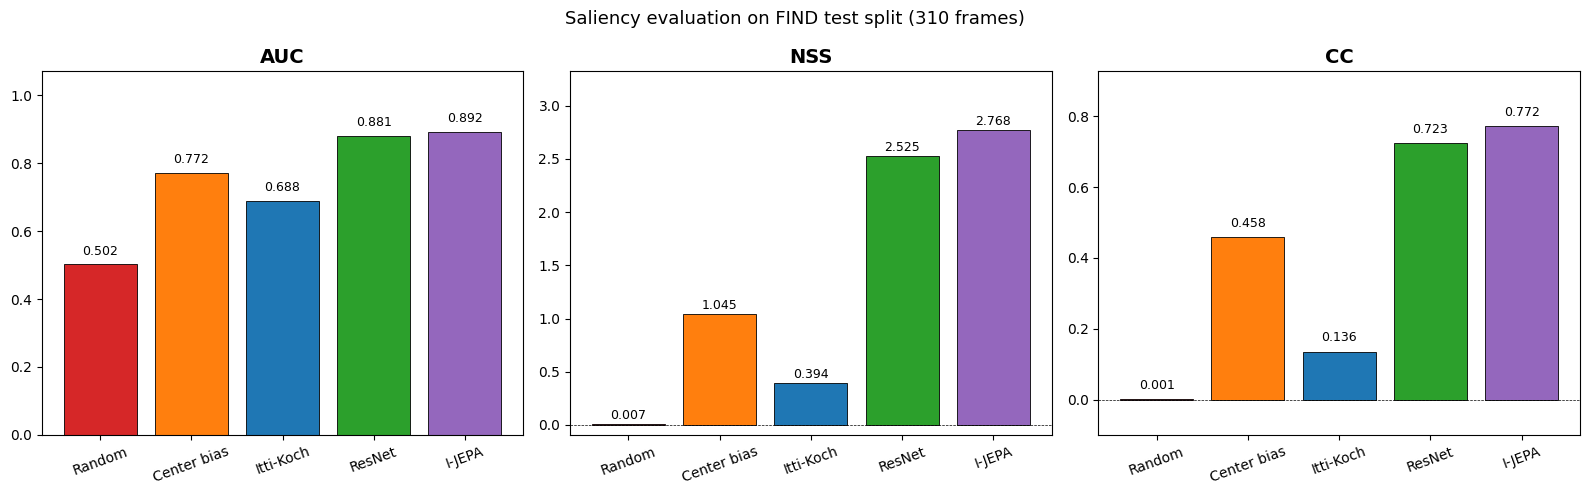

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c', '#9467bd']
labels = ['Random', 'Center bias', 'Itti-Koch', 'ResNet', 'I-JEPA']

for ax, metric in zip(axes, ['AUC', 'NSS', 'CC']):
    vals = df[metric].values
    bars = ax.bar(labels, vals, color=colors, edgecolor='black', linewidth=0.6)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_ylim(min(0, vals.min() - 0.1), vals.max() * 1.2)
    ax.tick_params(axis='x', rotation=20)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    for bar, val in zip(bars, vals):
        ypos = bar.get_height() + 0.02 if val >= 0 else bar.get_height() - 0.15
        ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Saliency evaluation on FIND test split (310 frames)', fontsize=13)
plt.tight_layout()
plt.savefig('../report_arash/figures/metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. The SaccadeJEPA Fix

The entire change needed to turn SaccadeJEPA into a content-driven gaze simulator is replacing one line.

**Before — `saccade.py` line 66 (original SaccadeJEPA):**
```python
translations = torch.empty(b, 2).uniform_(-max_frac, max_frac)  # random, no content
```

**After — saliency-driven replacement:**
```python
from src.saliency.ijepa_saliency import IJepaSaliency

saliency_model = IJepaSaliency.load('checkpoints/ijepa_saliency_best.pt')

# images: (B, 3, 224, 224) ImageNet-normalized
with torch.no_grad():
    saliency = saliency_model(images)       # (B, 224, 224) probability map

# Sample one fixation per image from the saliency distribution
flat    = saliency.view(b, -1)              # (B, 224*224)
indices = torch.multinomial(flat, 1).squeeze(1)     # (B,)
ys = (indices // 224).float() / 224 * 2 - 1         # normalize to [-1, 1]
xs = (indices %  224).float() / 224 * 2 - 1
translations = torch.stack([xs, ys], dim=1)          # (B, 2)
```

The saliency model outputs a probability distribution over all pixel locations. Sampling from it produces fixations that match where humans actually look — replacing the original uniform random translation with content-driven gaze targeting.


## 6. Conclusion and Limitations

### Key finding

**SaccadeJEPA is not a gaze simulator.** Its saccade targets are uniformly random (AUC = 0.502, chance level). Replacing the random line with a learned saliency model dramatically improves alignment with human fixation data:

| Metric | Random | Center bias | Itti-Koch | ResNetSaliency | I-JEPA Saliency |
|---|---|---|---|---|---|
| AUC  | 0.502 | 0.772 | 0.688 | 0.881 | **0.892** |
| NSS  | 0.007 | 1.045 | 0.394 | 2.525 | **2.768** |
| CC   | 0.001 | 0.458 | 0.136 | 0.723 | **0.772** |

### ResNet vs I-JEPA

Both learned models use the same setup: a frozen pretrained backbone with a lightweight 3×3 conv head trained on FIND fixation heatmaps using KL divergence loss. The difference is the backbone.

**ResNet-18** was pretrained on ImageNet with classification labels. Its features encode general visual concepts — objects, textures, human body parts — that correlate with where people look but were never shaped by a gaze signal.

**I-JEPA ViT-H/14** was pretrained entirely self-supervised: given visible image patches, predict the embeddings of masked patches — no labels, no pixel reconstruction. Its transformer features encode spatial context; every patch embedding reflects not just what is at that location but how it relates to the surrounding image. This richer representation gives I-JEPA a consistent advantage across all three metrics.

### Why center bias beats Itti-Koch

FIND is filmed with a camera operator keeping subjects in frame. Faces therefore appear near the center in most frames. A fixed central Gaussian exploits this filming bias without any image analysis. Itti-Koch uses actual image content but has no knowledge of camera framing conventions — it wins on image understanding but loses on dataset bias.

### Limitations

**Dataset specificity.** FIND is all social video — faces dominate every frame, and gaze in social scenes is strongly attracted to faces and hands. Both learned models essentially solve a face-localization task. On a diverse gaze dataset (natural scenes, sports, abstract stimuli) both models would score lower, and the gap between backbones would likely widen.

**Single-frame models on video data.** Human gaze follows motion — where you look at frame *t* depends on what happened at frame *t-1*. Both models treat each frame independently, ignoring temporal dynamics entirely.

**Shallow decoder.** Two conv layers cannot learn complex spatial reasoning. State-of-the-art saliency models use deep decoders with skip connections at multiple backbone scales. Our head demonstrates that frozen features are sufficient on FIND, but is not designed for maximum accuracy on diverse datasets.

**Frozen backbone.** We train only the head (~150K–740K parameters) on ~3,700 frames. Fine-tuning the full backbone end-to-end on a larger gaze dataset would yield stronger generalization, at the cost of needing more data and careful regularization.
